## Задание 1

Попробуем определить тип популяции опоссумов по их размерам.

Описание датасета:

case: observation number  - номер наблюдения

site: The site number where the possum was trapped. - номер места, где был пойман опоссум

Pop: Population, either Vic (Victoria) or other (New South Wales or Queensland). - Популяция (либо виктория, либо Нижний Уэльс)

sex: Gender, either m (male) or f (female).

age: Age.

hdlngth: Head length, in mm.

skullw: Skull width, in mm. - ширина черепа

totlngth: Total length, in cm.

taill: Tail length, in cm. - длина хвоста

footlgth: foot length - длина ног

earconch: ear conch length - длина ушной раковины

eye: distance from medial canthus to lateral canthus of right eye - расстояние от медиального угла глазной щели до латерального угла глазной щели правого глаза

chest: chest girth (in cm) - обхват груди

belly: belly girth (in cm) - обхват живота




Для выполнения задания:

1) Выберите и оставьте числовые признаки, по которым будете определять тип животных, и целевую переменную - Рор
2) Закодируйте значения по столбцу Рор в 0 и 1 (можно использовать метод LabelEncoder)
3) Разделите данные на выборку для обучения и тестирования (в соотношении 80 - тренировочная, 20 - тестовая)
4) Постройте модель LDA
5) Рассчитайте точность вашей модели на тестовой выборке

In [61]:
import pandas as pd
import scipy.stats as st
from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data_opposum = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/hw7/Файлы_к_ДЗ_Классификация_и_кластеризация/possum.csv')
data_opposum.head()
# data_opposum.groupby('Pop')['skullw'].describe()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [47]:
data_opposum = data_opposum.dropna()
data_opposum.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    object 
 3   sex       101 non-null    object 
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.8+ KB


In [12]:
data_opposum.groupby('Pop')['hdlngth'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,92.597826,2.734430,84.7,91.425,93.15,94.400,96.3
other,58.0,92.606897,4.143728,82.5,90.025,92.40,95.025,103.1


In [13]:
data_opposum.groupby('Pop')['totlngth'].describe()


,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,87.467391,4.845848,75.0,84.625,89.0,90.875,96.5
other,58.0,86.787931,3.850909,80.5,84.000,86.5,89.000,96.0


In [14]:
data_opposum.groupby('Pop')['taill'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,35.934783,1.717908,32.0,35.0,36.0,36.875,39.5
other,58.0,37.862069,1.713704,34.0,36.5,38.0,38.500,43.0


In [15]:
data_opposum.groupby('Pop')['footlgth'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,45.0,72.397778,2.582325,62.7,71.000,72.8,73.70,77.9
other,58.0,65.403448,2.770329,60.3,63.275,65.2,66.65,73.2


In [16]:

data_opposum.groupby('Pop')['earconch'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,52.186957,2.310325,40.3,51.400,52.15,53.375,56.2
other,58.0,44.913793,1.578968,41.3,43.825,44.90,46.000,48.0


In [17]:
data_opposum.groupby('Pop')['eye'].describe()


,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,14.871739,0.781924,13.0,14.400,14.9,15.375,16.4
other,58.0,15.184483,1.211176,12.8,14.425,15.0,16.000,17.8


In [18]:
data_opposum.groupby('Pop')['chest'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,27.445652,1.918414,23.0,27.000,28.0,28.375,31.0
other,58.0,26.646552,2.090095,22.0,25.125,26.0,28.000,32.0


In [19]:
data_opposum.groupby('Pop')['belly'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,46.0,32.663043,2.782993,25.0,31.125,32.5,34.375,40.0
other,58.0,32.525862,2.767960,27.0,30.625,32.5,34.000,39.0


In [20]:

data_opposum.groupby('Pop')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
Pop,,,,,,,,
Vic,44.0,4.022727,2.107447,1.0,2.0,3.5,5.25,9.0
other,58.0,3.689655,1.749254,1.0,3.0,3.0,5.00,7.0


В ходе расчета основных стат. характеристик данных, было отмечено, что данные числовые параметры животных в большей мере отличают две популяции друг от друга

1) earconch
2) footlgth
3) taill



In [49]:
data_opposum_copy = data_opposum[['Pop','earconch','footlgth','taill']]
data_opposum_copy.head()

,Pop,earconch,footlgth,taill
0,Vic,54.5,74.5,36.0
1,Vic,51.2,72.5,36.5
2,Vic,51.9,75.4,39.0
3,Vic,52.2,76.1,38.0
4,Vic,53.2,71.0,36.0


Кодирование популяции 

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data_opposum_copy['Pop'].values)
data_pop = le.transform(data_opposum_copy['Pop'].values)
data_pop


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Разделение выборки

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_opposum_copy[['earconch','footlgth','taill']], data_pop, test_size=0.2, random_state=42)
y_train


array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1])

Обучение модели

In [39]:
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# kmeans = KMeans(n_clusters=2)

# # fit_predict обучается на данных и каждому объекту присваивает кластер
# X_scaled = scaler.fit_transform(X_train)
# clusters = kmeans.fit_predict(X_scaled)

In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
## создаем экземпляр класса
lda = LinearDiscriminantAnalysis()


In [54]:
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [55]:
lda.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [57]:
result = pd.DataFrame([y_test, lda.predict(X_test)]).T
result

,0,1
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


Расчет точности

In [58]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, lda.predict(X_test))

1.0

In [59]:
lda.coef_

array([[-3.15292935, -1.36279061,  2.42509615]])

In [68]:
# Создаем сетку координат
x_min, x_max = X_train['taill'].min() - 1, X_train['taill'].max() + 1
y_min, y_max = X_train['footlgth'].min() - 1, X_train['footlgth'].max() + 1
## создается сетка размером 300 между x-min и x-max и аналогично с y
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),  ## создает 300 точек по оси X
                     np.linspace(y_min, y_max, 300))
##  meshgrid делает из них матрицы xx и yy размером 300x300, где каждая пара (xx[i,j], yy[i,j]) — это точка в пространстве признаков.


# Создаем "фиктивный" третий признак (earconch), устанавливаем среднее значение - это делается потому, что на вход модель получает 3 признака, а строим мы по 2 признакам. 
## Поэтому надо зафиксировать третий признак на его среднем значении, чтобы оно не изменялось, и график будет двумерным. То есть по сути это сечение трехмерного пространства 
earconch_mean = X_train['earconch'].mean()
grid = np.c_[np.full(xx.ravel().shape, earconch_mean), yy.ravel(), xx.ravel()]  # порядок: earconch, footlgth, taill

""".ravel() превращает 2D-сетку (300 x 300) в 1D-массив (90000, т.е. 300×300).[1,2,3,.....90000]
np.full(xx.ravel().shape, earconch_mean) - cоздаёт массив длиной 90000, заполненный средним значением признака earconch. [earconch_mean,earconch_mean,earconch_mean......]
np.c_[ ... ] - склеивает массивы по столбцам - Получается массив формы (90000, 3), где каждая строка — точка с 3 признаками"""
grid




array([[48.10375   , 59.3       , 31.        ],
       [48.10375   , 59.3       , 31.04347826],
       [48.10375   , 59.3       , 31.08695652],
       ...,
       [48.10375   , 78.9       , 43.91304348],
       [48.10375   , 78.9       , 43.95652174],
       [48.10375   , 78.9       , 44.        ]])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


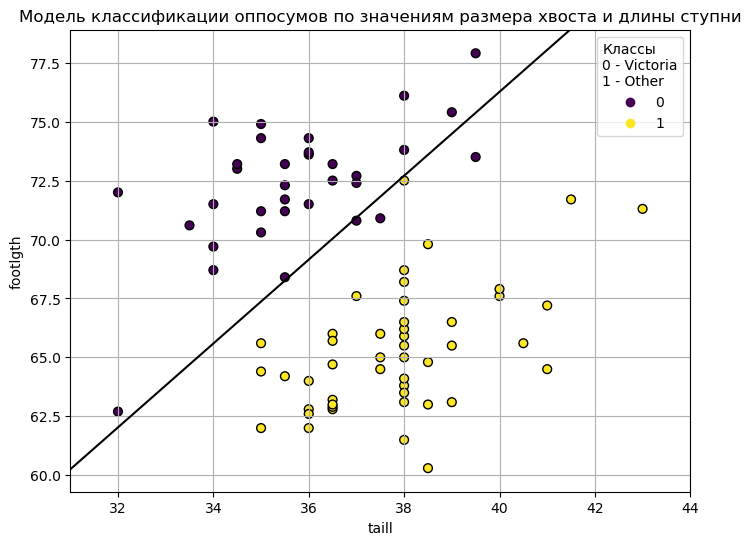

In [92]:
# Предсказываем вероятности для всей сетки
## выдает массив вероятностей принадлежности ко 2 классу (other)
Z = lda.predict_proba(grid)[:, 1]
Z
## преобразуем посчитанные вероятности обратно в форму 2d (массив с числами)
Z = Z.reshape(xx.shape)


# Визуализация: точки + линия разделения
plt.figure(figsize=(8, 6))

scatter = plt.scatter(x=X_train['taill'], y=X_train['footlgth'], c=y_train, edgecolor='k', s=40, cmap='viridis')
## То есть, это граница между двумя классами, по которой модель "сомневается", к какому отнести точку. Это и есть разделяющая линия (decision boundary) для LDA (или любой классификации по вероятностям).

"""Нельзя построить линию разделения напрямую по X и Y, потому что LDA или любая классификаторная модель работает не напрямую с координатами, а с предсказанными классами или вероятностями.

Чтобы нарисовать, где именно модель проводит границу, нужно:

На 2D-сетке разделить все координатами xx, yy (всё пространство, где может быть точка)
Вычислить для каждой точки вероятность того, что она принадлежит к определённому классу - это и есть Z
Построить контур, где эта вероятность = 0.5 
То есть, это граница между двумя классами, по которой модель "сомневается", к какому отнести точку.
Это и есть разделяющая линия  для LDA (или любой классификации по вероятностям).  
"""
plt.contour(xx, yy, Z, levels=[0.5], colors='black',)  # Линия, где p=0.5

plt.xlabel('taill')
plt.ylabel('footlgth')
plt.title('Модель классификации оппосумов по значениям размера хвоста и длины ступни')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Классы\n0 - Victoria\n1 - Other") ## генерируются элементы легенды 
plt.show()



## Задание 2

Теперь кластеризируем страны на основании показателей импорта и экспорта. Для работы используйте набор данных “Country-data.csv”, приложенный к материалам занятия.

Описание датасета:

country: Name of the country

child_mort: Death of children under 5 years of age per 1000 live births - Смертность детей в возрасте до 5 лет на 1000 живорождений

exports: Exports of goods and services per capita. Given as %age of the GDP per capita - Экспорт товаров и услуг на душу населения. Приведено в % от ВВП на душу населения.

health: Total health spending per capita. Given as %age of GDP per capita
imports: Imports of goods and services per capita. Given as %age of the GDP per capita

income: Net income per person - Чистый доход на человека

inflation: The measurement of the annual growth rate of the Total GDP - Измерение годового темпа роста общего ВВП

life_expec: The average number of years a new born child would live if the current mortality patterns are to remain the same - 
Среднее количество лет, которое проживет новорожденный ребенок, если нынешние показатели смертности останутся прежними

total_fer: The number of children that would be born to each woman if the current age-fertility rates remain the same. - Число детей, которое родится у каждой женщины, если текущие возрастные коэффициенты рождаемости останутся прежними.

gdpp: The GDP per capita. Calculated as the Total GDP divided by the total population. - ВВП на душу населения. Рассчитывается как общий ВВП, деленный на общую численность населения.

Для выполнения задания:

1) Выберите и оставьте только те признаки, по которым будете проводить кластерный анализ.
2) Подберите оптимальное число кластеров для алгоритма K-means.
3) Визуализируйте полученную кластеризацию.
4) Проверьте правильность выбора кластеров с помощью метода локтя.
5) Примените алгомеративную кластеризацию с учётом рассчитанного методом локтя оптимального количества кластеров.
6) Визуализируйте результат.

In [99]:
data_country = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/hw7/Файлы_к_ДЗ_Классификация_и_кластеризация/Country-data.csv')
data_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [98]:
data_country['imports'].describe()

count    167.000000
mean      46.890215
std       24.209589
min        0.065900
25%       30.200000
50%       43.300000
75%       58.750000
max      174.000000
Name: imports, dtype: float64

In [97]:
data_country['exports'].describe()

count    167.000000
mean      41.108976
std       27.412010
min        0.109000
25%       23.800000
50%       35.000000
75%       51.350000
max      200.000000
Name: exports, dtype: float64

Примерное приблизительное количество кластеров - 8 (по уровню экспорта - 0-25, 25 - 50, 50- 75, 75 - 100, 125 - 150, 150 - 175, 175 - 200)

Для разделения на кластеры будем использовать следующие столбцы: inflation и gdpp


Подготавливаем данные 

In [105]:
data_country['sum'] = data_country['exports'] + data_country['imports']
data_country_klast = data_country[['inflation','gdpp','sum']]
data_country_klast.head()

,inflation,gdpp,sum
0,9.44,553,54.9
1,4.49,4090,76.6
2,16.10,4460,69.8
3,22.40,3530,105.2
4,1.44,12200,104.4


Разделяем данные

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_country_klast[['inflation','gdpp']], data_country_klast['sum'], test_size=0.2, random_state=42)
X_train

,inflation,gdpp
158,1.57,38900
2,16.10,4460
100,1.13,8000
126,2.61,563
68,5.47,41900
...,...,...
71,15.90,6530
106,7.64,419
14,15.10,6030
92,2.04,4540


Приведем данные к единому виду


In [109]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_scaled

array([[-5.94997472e-01,  1.34620671e+00],
       [ 6.70789172e-01, -4.58324500e-01],
       [-6.33328244e-01, -2.72841327e-01],
       [-5.04397464e-01, -6.62513179e-01],
       [-2.55247443e-01,  1.50339584e+00],
       [-1.09852444e+00, -1.26131473e-01],
       [-2.57860905e-01, -4.06452087e-01],
       [ 3.39750683e-01, -6.79908776e-01],
       [-1.04537815e-01, -2.57122414e-01],
       [-8.02506335e-01, -9.99332846e-02],
       [-4.80876308e-01, -3.19998066e-01],
       [ 3.22327605e-01, -6.67962403e-01],
       [-3.94632070e-01, -6.51719526e-01],
       [-2.00364746e-01, -5.22772043e-01],
       [ 8.71808922e-04, -1.05172922e-01],
       [-2.34339749e-01, -4.28982529e-01],
       [-8.17751529e-01,  5.34062871e-01],
       [-9.84397378e-02, -2.16777204e-01],
       [-8.36301212e-02,  3.92592655e-01],
       [-2.56989751e-01, -6.57325938e-01],
       [-3.51074374e-01, -6.54915705e-01],
       [-5.48820419e-02, -5.23296007e-01],
       [-4.59968614e-01, -6.50828787e-01],
       [ 3.

Визуализируем данные

/var/folders/07/xx2bf7ss4g30z8mzlm1lcbqr0000gn/T/ipykernel_35269/2915422059.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_scaled[:, 0], X_scaled[:, 1],cmap='viridis', s=60)


Text(0, 0.5, 'gdpp')

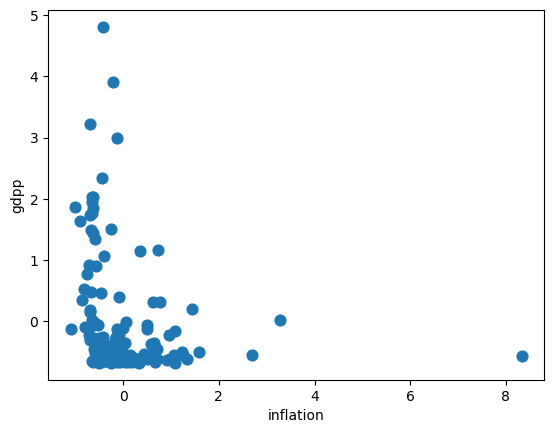

In [144]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],cmap='viridis', s=60)
plt.xlabel('inflation')
plt.ylabel('gdpp')

Обучение

In [125]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8)
# fit_predict обучается на данных и каждому объекту присваивает кластер
clusters = kmeans.fit_predict(X_scaled)
clusters

array([1, 7, 5, 0, 1, 5, 0, 7, 0, 5, 0, 7, 0, 0, 0, 0, 5, 0, 6, 0, 0, 0,
       0, 7, 1, 7, 5, 5, 3, 0, 0, 0, 0, 5, 7, 4, 0, 0, 7, 0, 1, 5, 0, 0,
       0, 0, 6, 5, 0, 7, 0, 0, 0, 5, 1, 0, 1, 7, 0, 5, 1, 0, 6, 4, 5, 0,
       3, 0, 3, 1, 7, 7, 3, 0, 3, 0, 0, 1, 0, 0, 1, 5, 7, 6, 1, 4, 7, 0,
       0, 7, 1, 1, 2, 5, 7, 7, 0, 7, 4, 5, 0, 7, 1, 0, 7, 7, 1, 0, 0, 0,
       0, 7, 0, 7, 6, 0, 0, 3, 0, 0, 3, 7, 7, 0, 1, 5, 7, 0, 7, 0, 7, 0,
       7], dtype=int32)

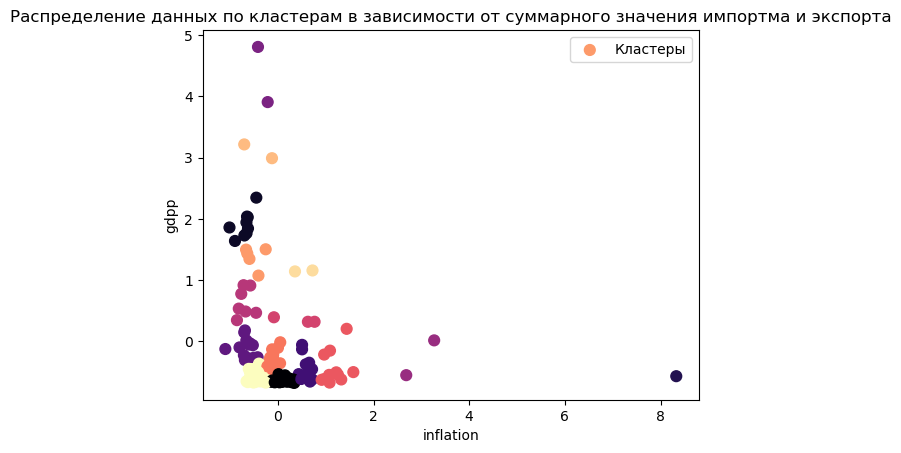

In [145]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], cmap='magma', c=clusters, s=60, label= 'Кластеры')
plt.legend()
plt.xlabel('inflation')
plt.ylabel('gdpp')
plt.title('Распределение данных по кластерам в зависимости от суммарного значения импортма и экспорта')
plt.show()


Строим график "локтя"

In [119]:
# строим график локтя

# создаем список для инерции
k_inertia = []
# задаем диапазон кластеров
ks = range(1, 20)

for k in ks:
    clf_kmeans = KMeans(n_clusters=k)
    clusters_kmeans = clf_kmeans.fit_predict(X_scaled)
    # добавляем инерцию каждой модели в список
    k_inertia.append(clf_kmeans.inertia_)

Text(0.5, 1.0, 'График локтя')

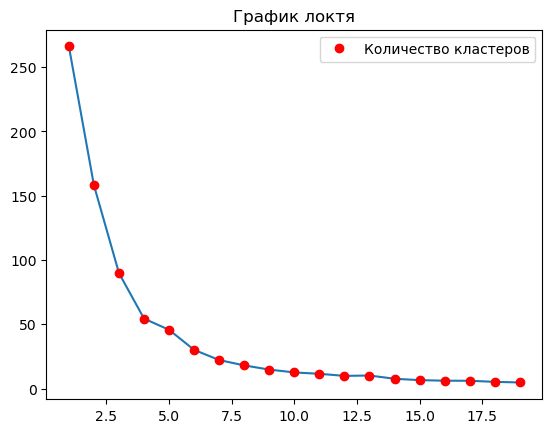

In [140]:
plt.plot(ks, k_inertia)
plt.plot(ks, k_inertia ,'ro', label = 'Количество кластеров')
plt.legend()
plt.title('График локтя')

Приблизительно необходимое количество кластеров - 15

Таким образом, делаем вывод, что 8 кластеров для корректного отображения - мало

In [146]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=15)
# fit_predict обучается на данных и каждому объекту присваивает кластер
clusters = kmeans.fit_predict(X_scaled)
clusters

array([ 2,  6, 11,  0,  2, 11,  8,  6,  8, 11, 11,  6,  0,  8,  8,  8,  5,
        8,  5,  0,  0,  8,  0,  6, 13,  1, 11, 11,  1,  8,  8,  0,  8,  5,
        6,  4,  8, 11,  6,  0, 13, 11,  0,  0, 11,  8, 12,  5,  0,  1,  8,
        8,  8, 11,  2,  0,  2,  8,  0, 11, 13,  8,  9, 14,  5,  0,  1,  8,
        7, 13,  1,  9,  1,  0,  1,  0,  0, 13,  8,  8, 13,  5,  6,  9, 13,
       10,  8,  8,  0,  9, 13, 13,  3,  5,  6,  1,  0,  6, 14,  5,  0,  6,
        2,  8,  6,  6,  2,  0,  0,  8,  8,  6,  0,  1, 12,  0,  0,  1,  8,
        0,  7,  1,  6,  0,  2, 11,  6,  0,  6,  8,  6,  0,  6],
      dtype=int32)

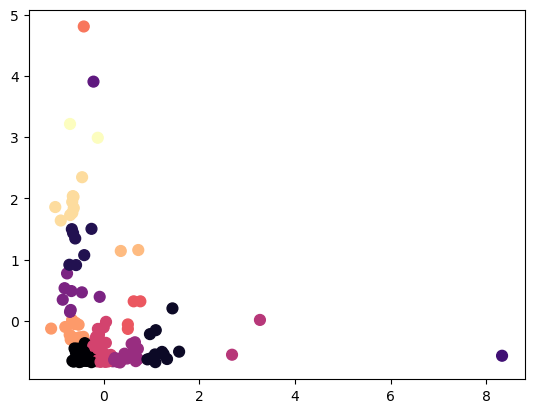

In [147]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], cmap='magma', c=clusters, s=60)